# Who eats like a Groninger? 🍳
## Finding the eierbal's hidden cousins in Dutch snack culture

If you have spent any time in Groningen, you know the eierbal, a deep-fried egg
wrapped in minced meat, sold at pretty much every frituur in the city.
Locals are fiercely proud of it. Visitors are confused by it.
The rest of the Netherlands has mostly never heard of it.

But here is the question that actually interested me:
**are there any national Dutch snacks that behave like the eierbal?**
Not in terms of what they are, but in terms of *when* people search for them.
Do any snacks share the same seasonal rhythm, the same quiet obscurity,
the same pattern of occasional spikes?

To find out, I used Google Trends data for 11 Dutch snacks from 2004 to 2026
and applied PCA to map their search patterns, then measured who sits
closest to the eierbal in that space.

**Data:** Google Trends, Netherlands, 2004 to 2026  
**Note:** Google Trends reports relative search interest on a scale of 0 to 100.
We use this as a proxy for how much attention each snack gets over time,
not absolute consumption, but awareness and curiosity.


## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', font_scale=1.1)

EIERBAL_COLOR   = '#E87A4C'
NEIGHBOUR_COLOR = '#55A868'
OTHER_COLOR     = '#888780'

## 2. Getting the data together

Google Trends only lets you compare 5 terms at a time, so I ran three separate queries
and included **eierbal** in all of them as a common reference point.
That way, when merging the files, everything stays on the same scale.

Two snacks, *satekroket* and *nasibal*, had almost no search data at all
and were dropped. The remaining 11 snacks cover a good range of Dutch frituur culture.


In [ ]:
g1 = pd.read_csv('data/Group_1.csv', parse_dates=['Time'])
g2 = pd.read_csv('data/Group_2.csv', parse_dates=['Time'])
g3 = pd.read_csv('data/Group_3.csv', parse_dates=['Time'])

df = g1.copy()
for g in [g2, g3]:
    cols = [c for c in g.columns if c not in df.columns]
    df = df.merge(g[['Time'] + cols], on='Time', how='inner')

df = df.drop(columns=['satekroket', 'nasibal'], errors='ignore')
snack_cols = [c for c in df.columns if c != 'Time']
df = df[df[snack_cols].gt(0).sum(axis=1) >= len(snack_cols) // 2].copy()

print(f'{len(df)} months of data, {len(snack_cols)} snacks')
print('Snacks included:', snack_cols)

234 months of data, 11 snacks
Snacks included: ['eierbal', 'bitterballen', 'kroket', 'frikandel', 'stroopwafel', 'bamischijf', 'kaassouffle', 'kipcorn', 'gehaktbal', 'mexicano', 'viandel']


## 3. Running the PCA

PCA takes all 11 snack search patterns, each one a time series of 234 months,
and finds the underlying dimensions that explain most of the differences between them.

Think of it like this: instead of looking at 11 separate lines on a chart,
PCA compresses them into a map where similar snacks end up close together
and different ones end up far apart.

The first component alone explains **86%** of all the variation.
That tells us one thing dominates the data: overall national popularity.
PC2 adds another 4%, picking up more subtle differences in timing and seasonality.


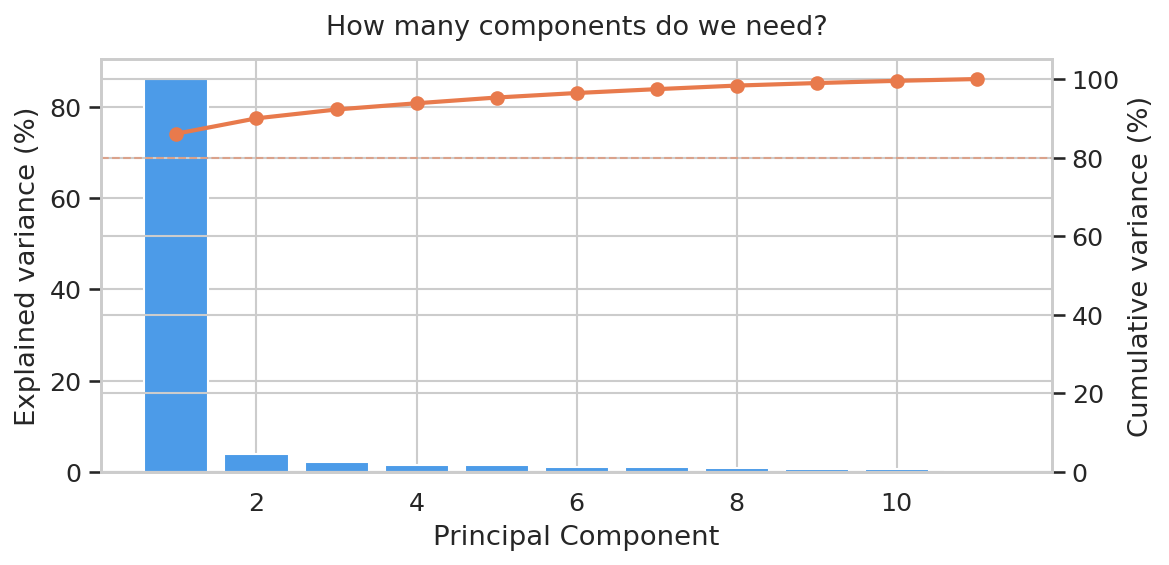

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[snack_cols])

pca_full = PCA()
pca_full.fit(X_scaled)
explained  = pca_full.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.bar(range(1, len(explained)+1), explained, color='#4C9BE8', edgecolor='white')
ax1.set_ylabel('Explained variance (%)')
ax1.set_xlabel('Principal Component')
ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative)+1), cumulative,
         color=EIERBAL_COLOR, marker='o', linewidth=2, markersize=6)
ax2.axhline(80, color=EIERBAL_COLOR, linestyle='--', linewidth=1, alpha=0.5)
ax2.set_ylabel('Cumulative variance (%)')
ax2.set_ylim(0, 105)
ax1.set_title('How many components do we need?', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

print(f'PC1: {explained[0]:.1f}%  |  PC2: {explained[1]:.1f}%  |  Together: {cumulative[1]:.1f}%')

## 4. The snack map and where the eierbal fits

Each arrow represents one snack. The direction it points tells us
how it relates to the two main components.
Snacks with arrows pointing in similar directions share similar search patterns.

The green arrows are the three snacks that sit closest to the eierbal
in this space: *kaassouffle*, *mexicano* and *stroopwafel*.
That last one might surprise you, and it surprised me too.


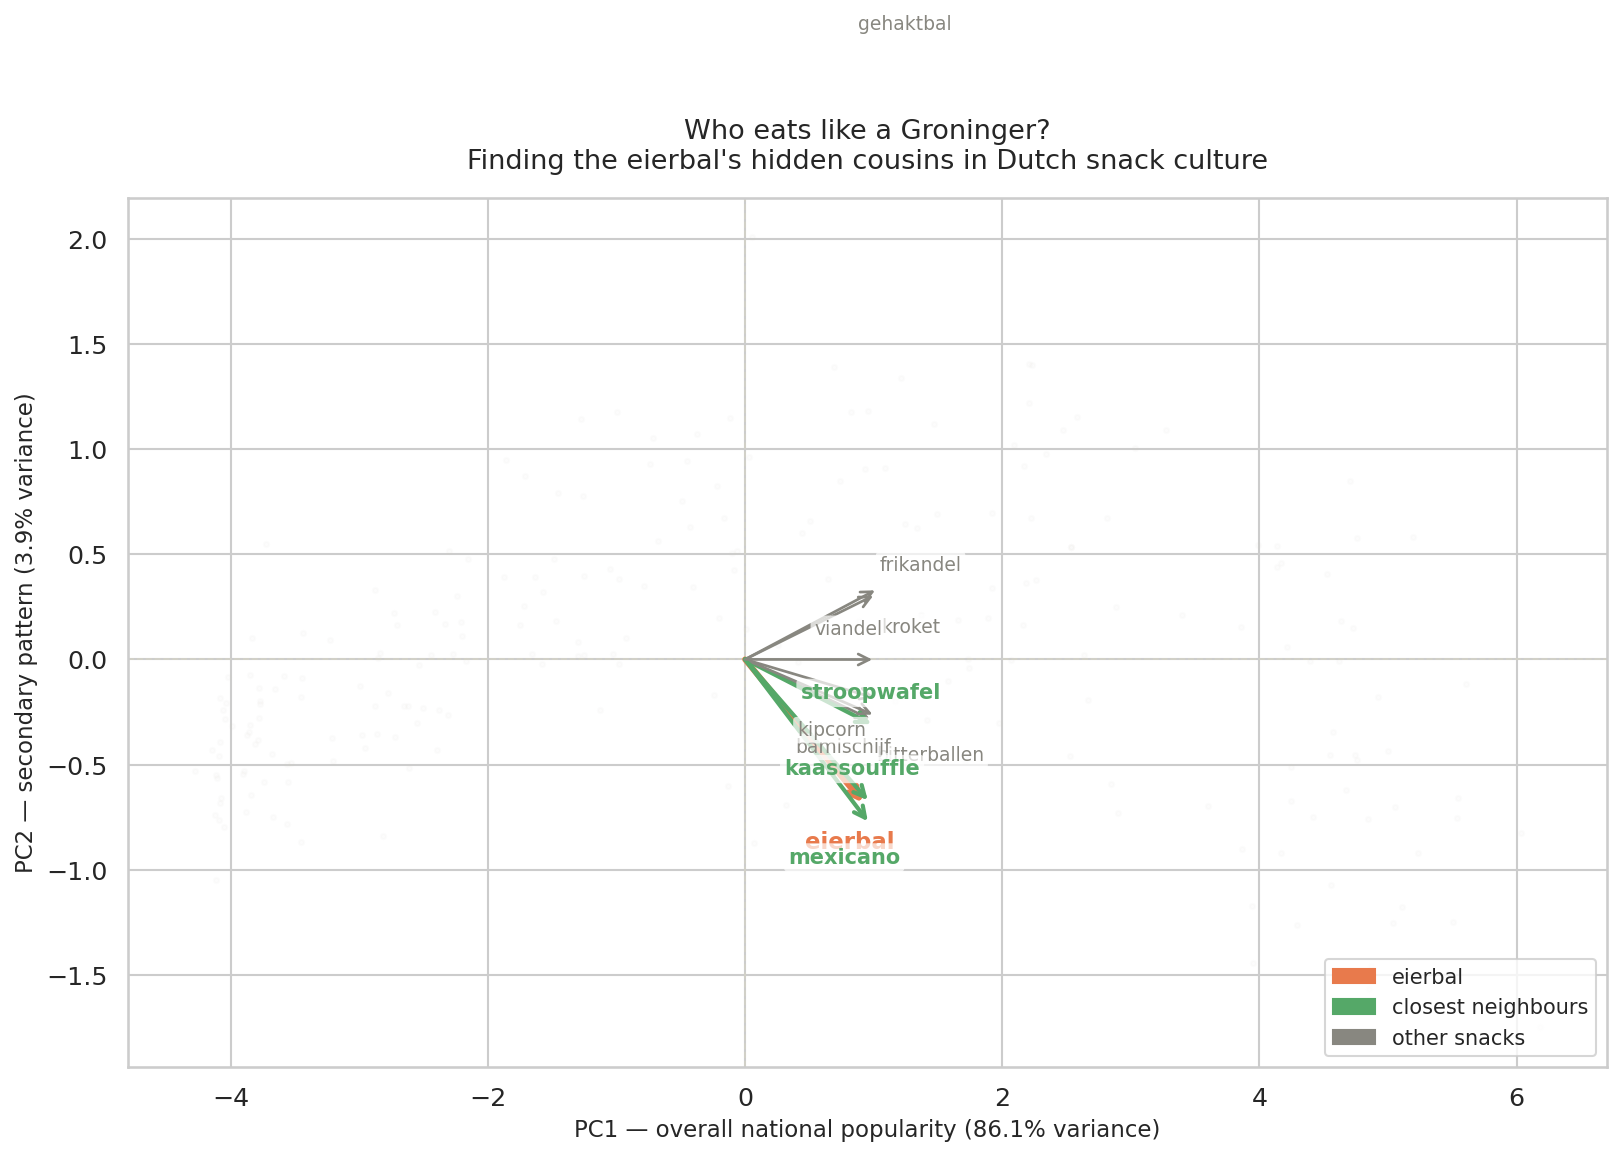

In [ ]:
pca2     = PCA(n_components=2)
scores   = pca2.fit_transform(X_scaled)
loadings = pca2.components_.T

eierbal_idx = snack_cols.index('eierbal')
eierbal_pos = loadings[eierbal_idx]
distances   = {s: np.linalg.norm(loadings[i] - eierbal_pos)
               for i, s in enumerate(snack_cols) if s != 'eierbal'}
closest = sorted(distances, key=distances.get)[:3]

label_offsets = {
    'eierbal':      (-0.45, -0.22),
    'bitterballen': ( 0.05, -0.20),
    'kroket':       ( 0.05, -0.20),
    'frikandel':    ( 0.05,  0.12),
    'stroopwafel':  (-0.55,  0.12),
    'bamischijf':   (-0.60, -0.18),
    'kaassouffle':  (-0.65,  0.12),
    'kipcorn':      (-0.60, -0.18),
    'gehaktbal':    ( 0.05,  0.12),
    'mexicano':     (-0.62, -0.20),
    'viandel':      (-0.45,  0.12),
}

scale = 3.2
fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(scores[:, 0], scores[:, 1], alpha=0.05, s=6, color='#D3D1C7', zorder=1)

for i, snack in enumerate(snack_cols):
    x, y = loadings[i, 0] * scale, loadings[i, 1] * scale
    if snack == 'eierbal':
        color, lw, fontw, fs = EIERBAL_COLOR, 2.8, 'bold', 11
    elif snack in closest:
        color, lw, fontw, fs = NEIGHBOUR_COLOR, 2.0, 'bold', 10
    else:
        color, lw, fontw, fs = OTHER_COLOR, 1.3, 'normal', 9
    ax.annotate('', xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                shrinkA=0, shrinkB=0))
    ox, oy = label_offsets.get(snack, (0.1, 0.1))
    ax.text(x+ox, y+oy, snack, fontsize=fs, color=color,
            fontweight=fontw, zorder=6,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7))

ax.axhline(0, color='#D3D1C7', linewidth=0.8, linestyle='--')
ax.axvline(0, color='#D3D1C7', linewidth=0.8, linestyle='--')
ax.set_xlabel(f'PC1: overall national popularity ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2: secondary pattern ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.set_title("Who eats like a Groninger?\nFinding the eierbal's hidden cousins",
             fontsize=13, pad=14)
orange = mpatches.Patch(color=EIERBAL_COLOR, label='eierbal')
green  = mpatches.Patch(color=NEIGHBOUR_COLOR, label='closest neighbours')
gray   = mpatches.Patch(color=OTHER_COLOR, label='other snacks')
ax.legend(handles=[orange, green, gray], fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

print('Closest snacks to eierbal:', closest)

## 5. How close is close?

To make it concrete, here is the Euclidean distance of each snack
from the eierbal in PCA space.
The smaller the distance, the more similar the search pattern.

The kaassouffle is remarkably close, almost identical in its PC trajectory.
The mexicano and the stroopwafel follow.
At the other extreme, the gehaktbal lives in a completely different world.


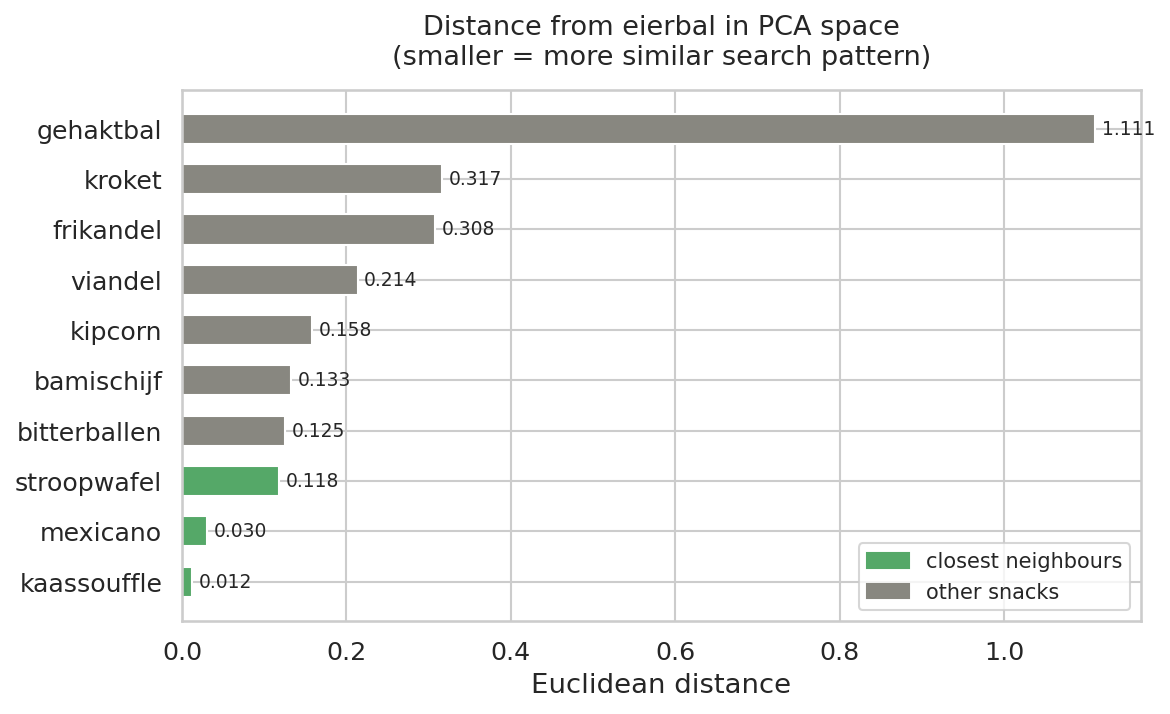

In [ ]:
dist_sorted = dict(sorted(distances.items(), key=lambda x: x[1]))
colors_dist = [NEIGHBOUR_COLOR if s in closest else OTHER_COLOR
               for s in dist_sorted]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(list(dist_sorted.keys()), list(dist_sorted.values()),
               color=colors_dist, edgecolor='white', height=0.6)
for bar in bars:
    ax.text(bar.get_width() + 0.008, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)
ax.set_title('Distance from eierbal in PCA space\n(smaller = more similar search pattern)',
             fontsize=13, pad=12)
ax.set_xlabel('Euclidean distance')
green_p = mpatches.Patch(color=NEIGHBOUR_COLOR, label='closest neighbours')
gray_p  = mpatches.Patch(color=OTHER_COLOR, label='other snacks')
ax.legend(handles=[green_p, gray_p], fontsize=10)
plt.tight_layout()
plt.show()

## 6. Do they share the same seasons?

PCA tells us the patterns are similar, but how are they similar exactly?
Looking at the average search interest by month gives a clearer picture.

All three eierbal neighbours show a comparable shape: relatively flat through the year
with modest peaks in autumn and winter, consistent with the idea that
these are cold weather comfort snacks rather than summer party food.
The eierbal follows the same rhythm, just at a much smaller scale.


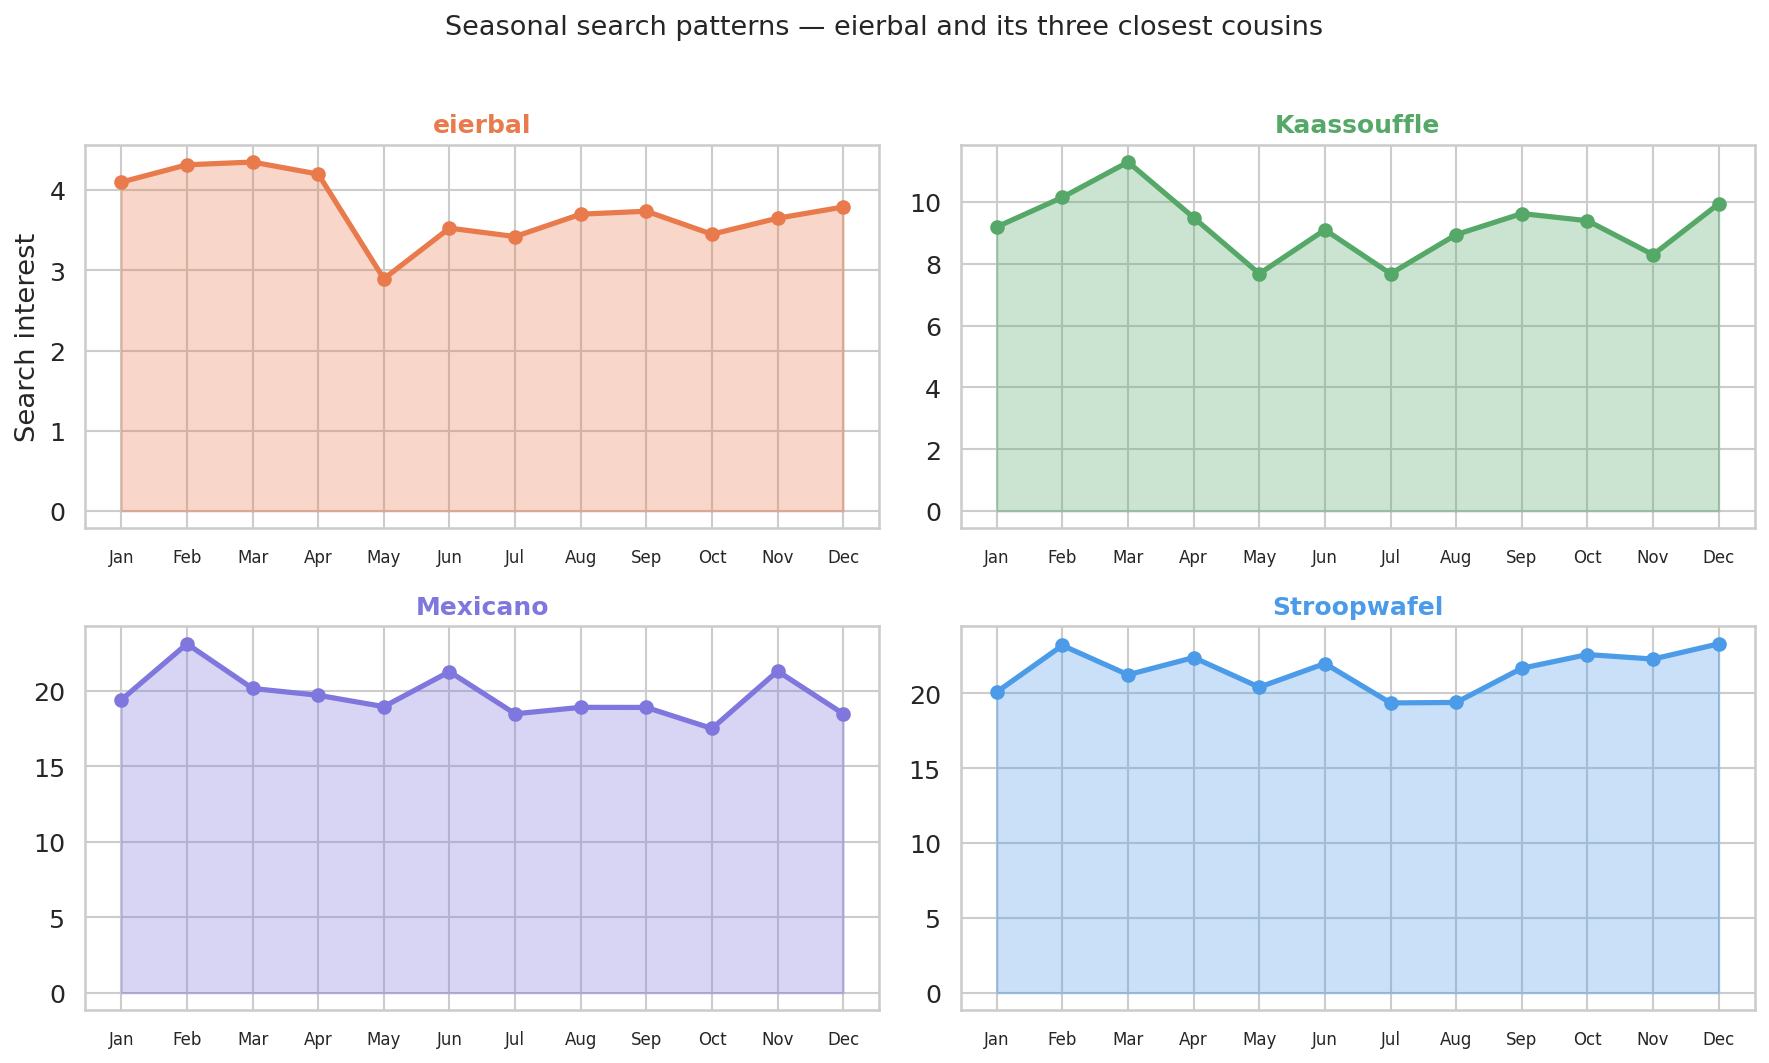

In [ ]:
df['month'] = df['Time'].dt.month
monthly = df.groupby('month')[snack_cols].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

neighbour_info = {
    'kaassouffle': ('#55A868', 'Kaassouffle'),
    'mexicano':    ('#7F77DD', 'Mexicano'),
    'stroopwafel': ('#4C9BE8', 'Stroopwafel'),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

ax = axes[0]
ax.fill_between(range(1,13), monthly['eierbal'], alpha=0.3, color=EIERBAL_COLOR)
ax.plot(range(1,13), monthly['eierbal'], color=EIERBAL_COLOR,
        linewidth=2.5, marker='o', markersize=6)
ax.set_title('eierbal', fontsize=12, fontweight='bold', color=EIERBAL_COLOR)
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_labels, fontsize=8)
ax.set_ylabel('Search interest')

for ax, (snack, (color, label)) in zip(axes[1:], neighbour_info.items()):
    ax.fill_between(range(1,13), monthly[snack], alpha=0.3, color=color)
    ax.plot(range(1,13), monthly[snack], color=color,
            linewidth=2.5, marker='o', markersize=6)
    ax.set_title(label, fontsize=12, fontweight='bold', color=color)
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(month_labels, fontsize=8)

fig.suptitle('Seasonal search patterns: eierbal and its three closest cousins',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. The correlation check

As a sanity check, here is the Pearson correlation between each snack
and the eierbal over the full 20 year period.
All snacks are fairly correlated, which makes sense since they all follow
a general long term upward trend in internet searches.
The key is that the PCA distance captures something more nuanced than raw correlation:
the shape of the pattern, not just whether it goes up and down together.


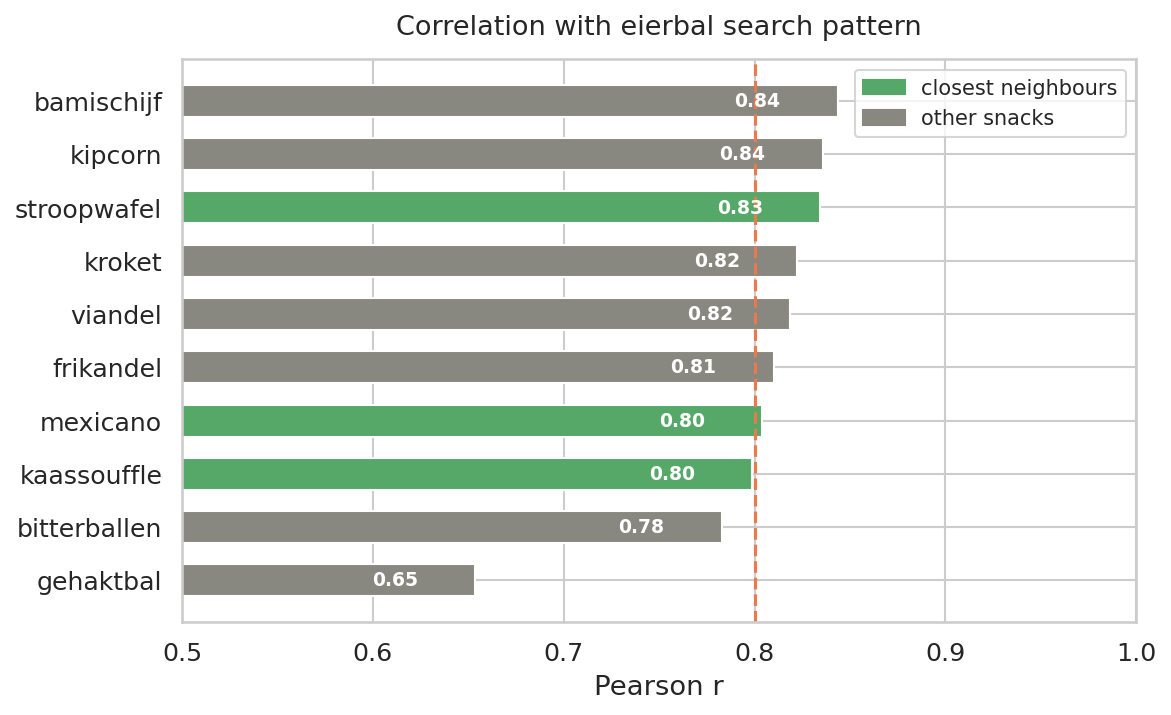

In [ ]:
corrs = {s: df['eierbal'].corr(df[s]) for s in snack_cols if s != 'eierbal'}
corrs_sorted = dict(sorted(corrs.items(), key=lambda x: x[1]))
colors_corr  = [NEIGHBOUR_COLOR if s in closest else OTHER_COLOR
                for s in corrs_sorted]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(list(corrs_sorted.keys()), list(corrs_sorted.values()),
               color=colors_corr, edgecolor='white', height=0.6)
ax.axvline(0.8, color=EIERBAL_COLOR, linestyle='--', linewidth=1.5,
           label='r = 0.80 reference line')
for bar in bars:
    ax.text(bar.get_width() - 0.03, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center', ha='right',
            fontsize=9, color='white', fontweight='bold')
ax.set_title('Correlation with eierbal search pattern', fontsize=13, pad=12)
ax.set_xlabel('Pearson r')
ax.set_xlim(0.5, 1.0)
green_p = mpatches.Patch(color=NEIGHBOUR_COLOR, label='closest neighbours')
gray_p  = mpatches.Patch(color=OTHER_COLOR, label='other snacks')
ax.legend(handles=[green_p, gray_p], fontsize=10)
plt.tight_layout()
plt.show()

## 8. So, who eats like a Groninger?

The answer, according to the data, is: people who eat **kaassouffle**, **mexicano** and **stroopwafel**.

That is a genuinely surprising result. The kaassouffle is a deep-fried cheese pocket,
which makes sense given the similar occasion and crowd. The mexicano is a spiced minced meat snack,
also plausible. But the stroopwafel? That one is harder to explain.
It might simply mean that all three occupy a similar niche in Dutch search behaviour:
not wildly popular, not forgotten, quietly consistent across the years.

| Finding | Detail |
|---|---|
| **Closest neighbour** | Kaassouffle, nearly identical PCA trajectory |
| **Second closest** | Mexicano, similar low key and consistent pattern |
| **Surprise entry** | Stroopwafel, unexpected but the data says so |
| **Most different** | Gehaktbal, completely different search behaviour |
| **PC1 explains** | 86% of all variance, national popularity dominates |

> The eierbal is not alone. Somewhere out there, kaassouffle lovers and eierbal lovers
> are searching Google at the same time of year, probably from the same kind of cold Tuesday evening.
> They just don't know it yet.

**Data:** Google Trends, Netherlands, 2004 to 2026  
**License:** Google Trends data is freely available for public use  
*Analysis by Debora Brigido, 2025*
